In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
df = pd.read_csv("train_and_test2.csv")
print(df.isnull().sum())


Passengerid    0
Age            0
Fare           0
Sex            0
sibsp          0
zero           0
zero.1         0
zero.2         0
zero.3         0
zero.4         0
zero.5         0
zero.6         0
Parch          0
zero.7         0
zero.8         0
zero.9         0
zero.10        0
zero.11        0
zero.12        0
zero.13        0
zero.14        0
Pclass         0
zero.15        0
zero.16        0
Embarked       2
zero.17        0
zero.18        0
2urvived       0
dtype: int64


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-null   int64  
 19  zero.13      1309

In [4]:
df = df.drop(columns=[col for col in df.columns if "zero" in col or "Unnamed" in col])
df = df.dropna(subset=["Embarked"])
df = df.rename(columns={'2urvived':'Survived'})
print(df.isnull().sum())

Passengerid    0
Age            0
Fare           0
Sex            0
sibsp          0
Parch          0
Pclass         0
Embarked       0
Survived       0
dtype: int64


In [5]:
mean_age = np.mean(df['Age'])
median_age = np.median(df['Age'])
mode_age = stats.mode(df['Age'])
mean_age


np.float64(29.471820964039786)

In [6]:
median_age


np.float64(28.0)

In [7]:
mode_age

ModeResult(mode=np.float64(28.0), count=np.int64(295))

In [8]:
df['Age'].value_counts()

Age
28.00    295
24.00     47
22.00     43
21.00     41
30.00     40
        ... 
60.50      1
11.50      1
0.33       1
0.17       1
38.50      1
Name: count, Length: 98, dtype: int64

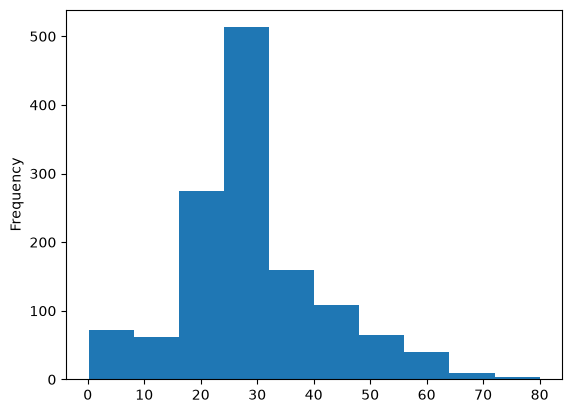

In [9]:
df['Age'].plot(kind ='hist',bins =10)
plt.show()

the data is right skewed as we can see because the value spread upto 80 while mean mean and median is 29.odd and 28 respectively which is also an indicator where mean is greater than median means right skewed 

In [10]:
population_variance = np.var(df['Age'])
population_std = np.std(df['Age'])

population_variance,population_std

(np.float64(165.80844855861176), np.float64(12.876662943426444))

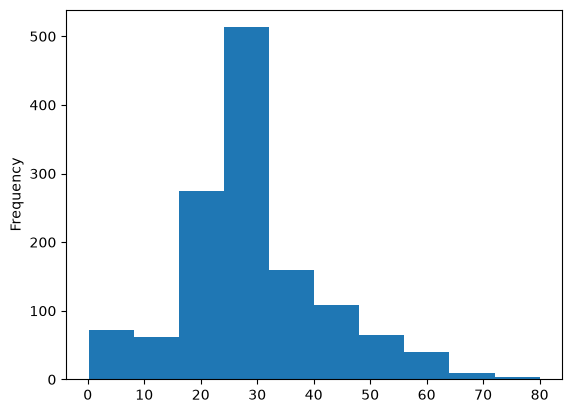

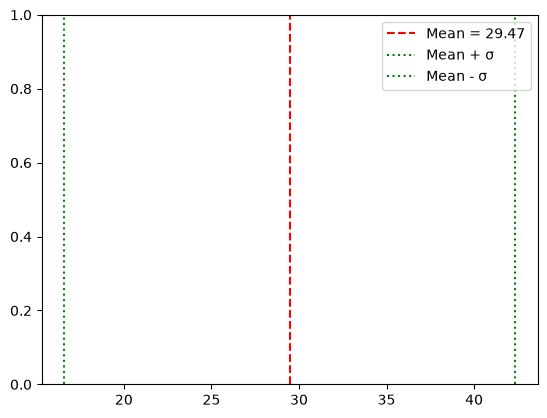

In [11]:
df['Age'].plot(kind ='hist',bins =10)
plt.show()
plt.axvline(mean_age, color="red", linestyle="--", label=f"Mean = {mean_age:.2f}")

# Add variance as spread (mean ± sqrt(var))
plt.axvline(mean_age + population_variance**0.5, color="green", linestyle=":", label="Mean + σ")
plt.axvline(mean_age - population_variance**0.5, color="green", linestyle=":", label="Mean - σ")

plt.legend()
plt.show()

In [12]:
df.groupby("Survived")["Age"].mean()

Survived
0    29.931748
1    28.163735
Name: Age, dtype: float64

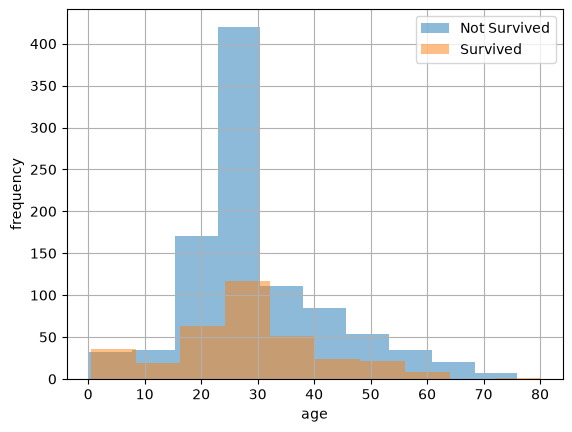

In [13]:
df[df["Survived"]==0]["Age"].hist(alpha=0.5, label="Not Survived")
df[df["Survived"]==1]["Age"].hist(alpha=0.5, label="Survived")
plt.xlabel("age")
plt.ylabel("frequency")
plt.legend()

This was analysis of age now it is analysis of further feilds and understand central tendency and pattern 

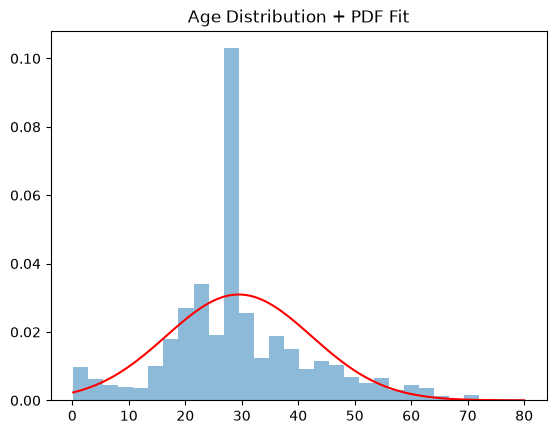

In [14]:
age = df["Age"].dropna()

mean = age.mean()
std = age.std()

x = np.linspace(age.min(), age.max(), 100)

pdf = stats.norm.pdf(x, loc=mean, scale=std)

plt.hist(age, bins=30, density=True, alpha=0.5)
plt.plot(x, pdf, 'r')
plt.title("Age Distribution + PDF Fit")
plt.show()

In [15]:
cdf_28 = stats.norm.cdf(28,loc=mean_age,scale=population_std)*100
cdf_28

np.float64(45.449942521644985)

In [16]:
cdf_children = stats.norm.cdf(20,loc=mean_age,scale=population_std)*100
cdf_children

np.float64(23.099304508270237)

In [17]:
cdf_100= stats.norm.cdf(100,loc=mean_age,scale=population_std)
cdf_60 = stats.norm.cdf(60,loc=mean_age,scale=population_std)
cdf_skewed_age_class = (cdf_100-cdf_60)*100
cdf_skewed_age_class

np.float64(0.8874447001137709)

In [18]:
cdf_old= stats.norm.cdf(100,loc=mean_age,scale=population_std)
cdf_youth = stats.norm.cdf(20,loc=mean_age,scale=population_std)
cdf_working_class = (cdf_old-cdf_youth)*100
cdf_working_class 

np.float64(76.90069333130056)

In [19]:
sample_means = []

for i in range(1000):
    sample = df["Age"].dropna().sample(30)
    sample_means.append(sample.mean())

now i will check the ci for age parameter 

In [20]:
sample = df["Age"].sample(100)
mean = sample.mean()
std = sample.std()
n = len(sample)
confidence = 0.95
alpha = 1- confidence
z = stats.norm.ppf(1-alpha/2)
ci_upper_bound = mean + z * std/(np.sqrt(n))
ci_lower_bound  = mean - z * std/(np.sqrt(n))

ci_upper_bound , ci_lower_bound


(np.float64(30.141986053630824), np.float64(25.144613946369176))

now i will do these above examnations with other features to check their importance and relationship in our classification 

In [24]:
df.to_excel("preprocessed_titanic_dataset.xlsx", index = False)